# 01 - Analise Exploratoria (EDA)

**O que este notebook faz:** carrega o dataset bruto, verifica a qualidade dos dados (nulos, duplicadas), explora a distribuicao do preco de venda e como ela varia por produto/regiao/estado/bandeira, e faz uma primeira olhada visual em possiveis outliers — tudo sem treinar nenhum modelo. E o passo 1 do fluxo EDA -> baseline -> modelos -> tuning -> avaliacao.

**Dataset:** Serie Historica de Precos de Combustiveis - ANP (Agencia Nacional do Petroleo, Gas Natural e Biocombustiveis)

Levantamento mensal de precos de venda de gasolina, gasolina aditivada e etanol por posto revendedor, coletado pela ANP em todo o Brasil. Fonte publica: https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis (referencia: dezembro/2025).

**Por que este dataset serve para deteccao de anomalias?** Nao existe rotulo de fraude/erro, mas o problema e naturalmente desbalanceado no sentido que interessa: a grande maioria dos postos vende pelo preco de mercado da sua regiao/produto, e so uma pequena fracao tem precos muito fora do padrao (erro de digitacao no boletim, posto muito acima ou abaixo da concorrencia). E exatamente o cenario de IsolationForest, LocalOutlierFactor e OneClassSVM: aprender o que e 'normal' e apontar os poucos pontos que destoam.

**Este notebook e SOMENTE EDA.** Nao ha split treino/teste nem modelagem aqui — isso comeca no notebook `02_preprocessing_baseline`.

## 1. Imports

In [1]:
import sys
sys.path.append('..')  # permite importar o pacote src/ a partir de notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # testes estatisticos (normalidade, Kruskal-Wallis) e MAD robusto

from src.data import carregar_dados  # funcao reutilizavel de carga/limpeza

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Carregar os dados

In [2]:
CAMINHO_DADOS = '../data/precos_combustiveis_anp_2025-12.csv'

df = carregar_dados(CAMINHO_DADOS)
print('Linhas x Colunas:', df.shape)
df.head()

Linhas x Colunas: (52336, 10)


,regiao,estado,municipio,revenda,cnpj_revenda,produto,data_coleta,valor_venda,unidade_medida,bandeira
0,NE,AL,ARAPIRACA,AUTO POSTO M M GARROTE LTDA,08.738.994/0001-50,GASOLINA,2025-12-01,6.14,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,AUTO POSTO M M GARROTE LTDA,08.738.994/0001-50,GASOLINA ADITIVADA,2025-12-01,6.14,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,AUTO POSTO M M GARROTE LTDA,08.738.994/0001-50,ETANOL,2025-12-01,4.79,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,AUTO POSTO MASSARANDUBA LTDA,07.248.398/0001-29,GASOLINA,2025-12-01,6.19,R$ / litro,BRANCA
4,NE,AL,ARAPIRACA,AUTO POSTO MASSARANDUBA LTDA,07.248.398/0001-29,GASOLINA ADITIVADA,2025-12-01,6.19,R$ / litro,BRANCA


**Resultado:** 52.336 registros e 10 colunas. `carregar_dados` ja descarta as colunas de endereco (rua, numero, complemento, bairro, cep) e a coluna `Valor de Compra` (100% vazia no arquivo original), que nao ajudam a explicar preco anomalo.

## 3. Visao geral e qualidade dos dados

Cada linha e uma coleta de preco: um produto (gasolina, gasolina aditivada ou etanol) vendido por um posto, em uma data especifica.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52336 entries, 0 to 52335
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   regiao          52336 non-null  str           
 1   estado          52336 non-null  str           
 2   municipio       52336 non-null  str           
 3   revenda         52336 non-null  str           
 4   cnpj_revenda    52336 non-null  str           
 5   produto         52336 non-null  str           
 6   data_coleta     52336 non-null  datetime64[us]
 7   valor_venda     52336 non-null  float64       
 8   unidade_medida  52336 non-null  str           
 9   bandeira        52336 non-null  str           
dtypes: datetime64[us](1), float64(1), str(8)
memory usage: 4.0 MB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
regiao,52336,5,SE,25722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estado,52336,27,SP,15534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
municipio,52336,397,SAO PAULO,3036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revenda,52336,5103,SIM REDE DE POSTOS LTDA,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cnpj_revenda,52336,5737,08.505.094/0001-62,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
produto,52336,3,GASOLINA,19948,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_coleta,52336,NaN,NaN,NaN,2025-12-15 14:40:57.597065,2025-12-01 00:00:00,2025-12-08 00:00:00,2025-12-16 00:00:00,2025-12-23 00:00:00,2025-12-31 00:00:00,NaN
valor_venda,52336.0,NaN,NaN,NaN,5.728101,3.49,4.79,5.99,6.39,9.59,0.908264
unidade_medida,52336,1,R$ / litro,52336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bandeira,52336,45,BRANCA,17003,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Valores nulos por coluna
nulos = df.isnull().sum().sort_values(ascending=False)
nulos[nulos > 0]

Series([], dtype: int64)

In [6]:
# Linhas duplicadas (mesmo posto + produto + data + preco)
print('Duplicadas:', df.duplicated().sum())

Duplicadas: 0


**Resultado:** nenhuma coluna com valor nulo e nenhuma linha duplicada. Os dados ja chegam limpos o suficiente para seguir direto para a analise — nao ha necessidade de imputacao ou deduplicacao antes do split treino/teste.

## 4. Cobertura geografica e temporal

Quantos estados/regioes estao representados e qual o periodo coberto — importante para saber se faz sentido comparar precos entre estados.

In [7]:
print('Estados:', df['estado'].nunique())
print('Regioes:', sorted(df['regiao'].unique()))
print('Periodo:', df['data_coleta'].min().date(), 'a', df['data_coleta'].max().date())
print('Bandeiras (marcas):', df['bandeira'].nunique())

Estados: 27
Regioes: ['CO', 'N', 'NE', 'S', 'SE']
Periodo: 2025-12-01 a 2025-12-31
Bandeiras (marcas): 45


In [8]:
df['produto'].value_counts().to_frame('registros')

,registros
produto,
GASOLINA,19948
ETANOL,16747
GASOLINA ADITIVADA,15641


**Resultado:** cobertura nacional completa — os 27 estados e as 5 regioes aparecem na base, com coleta ao longo de todo dezembro/2025 e 45 bandeiras distintas. Os 3 produtos tambem estao bem distribuidos (38% gasolina, 32% etanol, 30% gasolina aditivada), o que da uma base solida para estratificar o split treino/teste por `produto` no notebook 02 e para calcular medianas de referencia confiaveis por estado/produto.

## 5. Distribuicao do preco de venda

Preco (`valor_venda`) e a unica variavel numerica de interesse direto — e a partir dela que as futuras features de anomalia serao construidas.

In [9]:
df['valor_venda'].describe()

count    52336.000000
mean         5.728101
std          0.908264
min          3.490000
25%          4.790000
50%          5.990000
75%          6.390000
max          9.590000
Name: valor_venda, dtype: float64

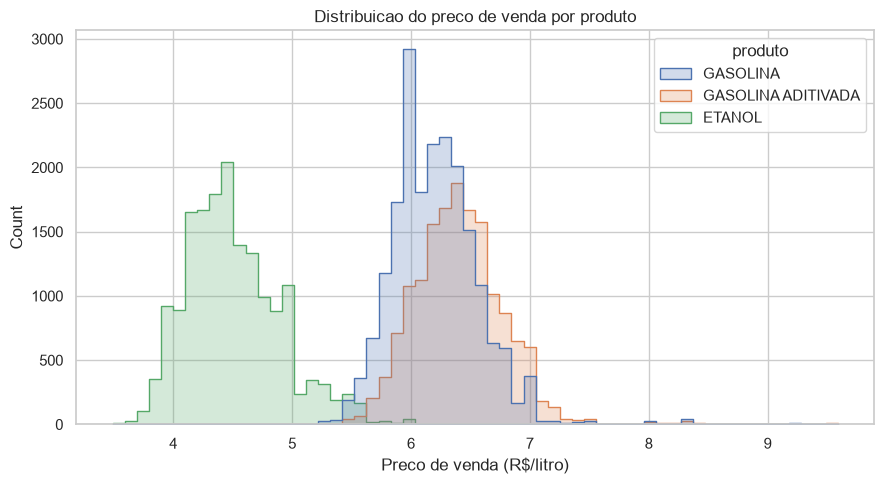

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x='valor_venda', hue='produto', bins=60, element='step', ax=ax)
ax.set_title('Distribuicao do preco de venda por produto')
ax.set_xlabel('Preco de venda (R$/litro)')
plt.tight_layout()
plt.savefig('../reports/eda_distribuicao_preco_por_produto.png', dpi=120)
plt.show()

**Resultado:** preco varia de R$ 3,49 a R$ 9,59 (media R$ 5,73). O histograma mostra tres distribuicoes bem separadas — etanol forma um agrupamento mais barato e a esquerda, gasolina e gasolina aditivada ficam mais caras e proximas entre si. Ou seja: o mesmo preco absoluto pode ser normal para um produto e anomalo para outro, entao qualquer analise de anomalia precisa comparar o preco dentro do proprio produto (e, como veremos a seguir, dentro da propria regiao).

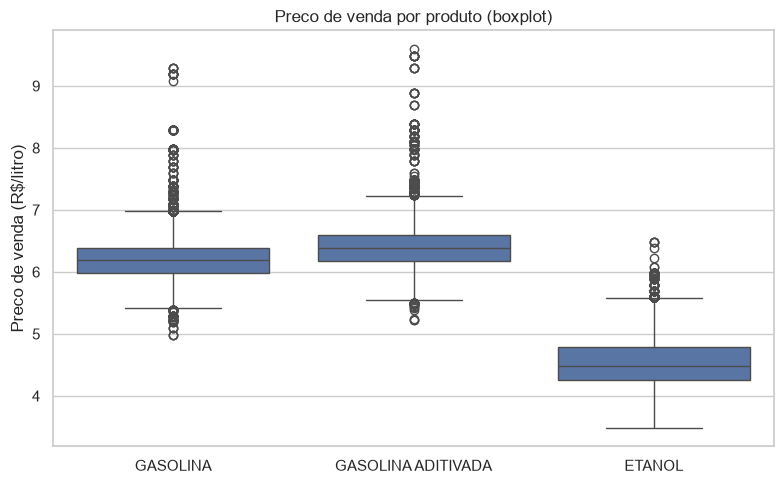

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='produto', y='valor_venda', ax=ax)
ax.set_title('Preco de venda por produto (boxplot)')
ax.set_xlabel('')
ax.set_ylabel('Preco de venda (R$/litro)')
plt.tight_layout()
plt.show()

**Resultado:** o boxplot confirma o etanol como o produto mais barato e com maior espalhamento relativo. Ja aparecem pontos fora dos bigodes (outliers univariados) nos tres produtos — candidatos naturais a anomalia, que os modelos dos proximos notebooks vao tentar capturar de forma sistematica.

### 5.1 Forma da distribuicao: assimetria, curtose e normalidade

O histograma sugere que cada produto tem uma cauda mais longa para a direita (poucos precos bem altos). Para sair do "parece" e ir para o "e", medimos isso formalmente:

- **Assimetria (skewness):** 0 = simetrica; positiva = cauda mais longa a direita (poucos precos muito altos puxando a media para cima); negativa = cauda mais longa a esquerda.
- **Curtose em excesso (excess kurtosis):** 0 = tao "pesada nas caudas" quanto uma normal; positiva (leptocurtica) = caudas mais pesadas que a normal, ou seja, valores extremos sao mais frequentes do que uma distribuicao normal preveria — exatamente o que importa para decidir se e seguro tratar `valor_venda` como aproximadamente normal.

Calculamos isso **por produto**, nunca no `valor_venda` agregado dos 3 produtos juntos: como vimos no histograma, misturar 3 distribuicoes com centros diferentes (etanol vs. gasolina vs. gasolina aditivada) cria uma forma artificial de mistura (multimodal) cuja assimetria/curtose agregada nao descreve bem nenhum dos grupos individualmente — um efeito parecido com o paradoxo de Simpson aplicado a forma da distribuicao.

In [12]:
forma = df.groupby('produto')['valor_venda'].agg(
    n='count',
    assimetria=lambda x: stats.skew(x),
    curtose_excesso=lambda x: stats.kurtosis(x),  # kurtosis() do scipy ja subtrai 3 (excesso)
)
forma

,n,assimetria,curtose_excesso
produto,,,
ETANOL,16747,0.699716,0.539209
GASOLINA,19948,1.187747,5.703161
GASOLINA ADITIVADA,15641,1.114078,5.359939


**Resultado:** os tres produtos tem assimetria positiva (ETANOL 0,70; GASOLINA ADITIVADA 1,11; GASOLINA 1,19) — confirma a cauda a direita que ja aparecia no histograma: ha mais espaco para precos "muito acima" do centro do que "muito abaixo" (faz sentido: preco tem um piso proximo do custo, mas nao tem teto). A curtose e onde a diferenca fica marcante: ETANOL tem curtose em excesso de apenas 0,54 (proxima de uma normal), enquanto GASOLINA (5,70) e GASOLINA ADITIVADA (5,36) sao fortemente leptocurticas — caudas bem mais pesadas que uma normal preveria. Na pratica isso quer dizer que, para gasolina e gasolina aditivada, valores extremos nao sao raridade estatistica tao rara quanto uma normal sugeriria — reforcando que metodos de deteccao de anomalia baseados em normalidade (como o z-score classico da secao 8) tendem a subestimar o problema justamente nesses dois produtos.

**Teste formal de normalidade.** Assimetria e curtose ja sao fortes indicios contra a normalidade, mas o teste de D'Agostino-Pearson (`scipy.stats.normaltest`) combina as duas em uma unica estatistica de hipotese: H0 = "a amostra vem de uma distribuicao normal". Preferimos este teste ao classico Shapiro-Wilk porque o Shapiro perde confiabilidade acima de ~5.000 amostras — aqui os grupos tem 15 a 20 mil linhas.

In [13]:
normalidade = df.groupby('produto')['valor_venda'].apply(
    lambda x: pd.Series(stats.normaltest(x), index=['estatistica', 'p_valor'])
).unstack()
normalidade

,estatistica,p_valor
produto,,
ETANOL,1252.109830,1.281755e-272
GASOLINA,5452.157828,0.000000e+00
GASOLINA ADITIVADA,3984.669220,0.000000e+00


**Resultado:** para os tres produtos o p-valor e essencialmente zero (ETANOL ≈1,3×10⁻²⁷²; GASOLINA e GASOLINA ADITIVADA abaixo da precisao de ponto flutuante) — rejeitamos H0 com folga em qualquer nivel de significancia usual (0,05, 0,01, 0,001...). `valor_venda` **nao** e normal em nenhum dos tres grupos, mesmo dentro de cada produto isoladamente.

Essa conclusao tem consequencias praticas diretas para o resto da analise:
- Justifica preferir **mediana e MAD** (estatisticas robustas, nao assumem normalidade) a **media e desvio-padrao** para definir o que e "preco tipico" — e e exatamente por isso que `ReferenciaPrecos` (notebook 02) usa a mediana, nao a media, como referencia.
- Justifica usar **Kruskal-Wallis** (nao-parametrico) em vez de ANOVA classica para comparar precos entre regioes/estados na proxima secao, ja que a ANOVA assume normalidade dos residuos.

## 6. Preco por regiao

Combustivel no Brasil varia bastante por regiao (frete, tributacao estadual). Ver essa variacao ajuda a decidir se a feature de anomalia deve comparar o preco contra a media nacional ou contra a media regional/estadual (decisao tomada no notebook 02).

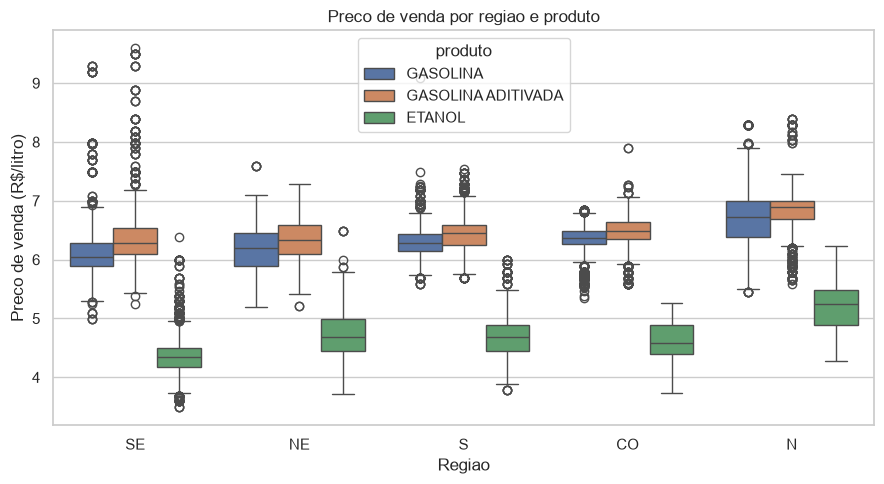

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ordem_regiao = df.groupby('regiao')['valor_venda'].median().sort_values().index
sns.boxplot(data=df, x='regiao', y='valor_venda', order=ordem_regiao, hue='produto', ax=ax)
ax.set_title('Preco de venda por regiao e produto')
ax.set_xlabel('Regiao')
ax.set_ylabel('Preco de venda (R$/litro)')
plt.tight_layout()
plt.savefig('../reports/eda_boxplot_preco_por_regiao.png', dpi=120)
plt.show()

In [15]:
mediana_estado = (
    df.groupby(['estado', 'produto'])['valor_venda']
    .median()
    .unstack('produto')
    .sort_values('GASOLINA')
)
mediana_estado

produto,ETANOL,GASOLINA,GASOLINA ADITIVADA
estado,,,
PI,4.490,5.79,6.020
PB,4.190,5.89,6.070
RN,4.490,5.94,6.030
MA,5.090,5.99,6.090
SP,4.190,5.99,6.290
RJ,4.690,5.99,6.290
MG,4.470,5.99,6.290
AP,5.790,6.07,6.375
MS,3.990,6.17,6.290


**Resultado:** a mediana da gasolina vai de R$ 5,79 no Piaui ate R$ 7,39 no Acre — quase R$ 1,60 de diferenca, com Norte/Nordeste distante concentrando os precos mais altos (AC, AM, RO, RR) e Nordeste os mais baixos (PI, PB, RN). Um preco de R$ 6,50 e comum no Acre e seria um forte candidato a anomalia no Piaui. Isso confirma que **preco bruto nao serve como feature de anomalia**: a feature precisa ser relativa a mediana do proprio grupo (estado + produto), o que sera implementado em `ReferenciaPrecos` no notebook 02.

### 6.1 O efeito de regiao/estado e estatisticamente significativo?

O boxplot e a tabela de medianas sugerem visualmente que a regiao importa, mas "parece diferente" nao e a mesma coisa que "e diferente". Testamos formalmente com **Kruskal-Wallis** — o equivalente nao-parametrico da ANOVA de um fator, apropriado aqui porque ja mostramos que `valor_venda` nao e normal em nenhum produto. H0 = "todas as regioes/estados tem a mesma distribuicao de preco" (dentro do mesmo produto, para nao misturar o efeito de produto com o de regiao).

Como o teste sozinho so diz "existe diferenca" mas nao "o quanto", tambem calculamos o **tamanho de efeito epsilon-quadrado** (ε² = (H − k + 1) / (n − k), o analogo do R² para Kruskal-Wallis): 0 = grupos indistinguiveis, 1 = grupos perfeitamente separados. Isso importa porque, com n na casa dos milhares, o p-valor tende a ficar minusculo mesmo para diferencas pequenas e pouco uteis na pratica — o p-valor confirma que existe efeito, o epsilon-quadrado diz se esse efeito e grande o bastante para importar.

In [16]:
def kruskal_por_coluna(df, coluna_grupo):
    """Roda Kruskal-Wallis de valor_venda por `coluna_grupo`, separadamente para
    cada produto, e devolve H, p-valor e o tamanho de efeito epsilon-quadrado."""
    linhas = []
    for produto, sub in df.groupby('produto'):
        grupos = [g['valor_venda'].to_numpy() for _, g in sub.groupby(coluna_grupo)]
        h, p = stats.kruskal(*grupos)
        k, n = len(grupos), len(sub)
        epsilon2 = (h - k + 1) / (n - k)
        linhas.append({'produto': produto, 'n_grupos': k, 'n': n, 'H': h, 'p_valor': p, 'epsilon2': epsilon2})
    return pd.DataFrame(linhas).set_index('produto')


print('--- Kruskal-Wallis por REGIAO (5 grupos) ---')
display(kruskal_por_coluna(df, 'regiao'))

print('--- Kruskal-Wallis por ESTADO (27 grupos) ---')
display(kruskal_por_coluna(df, 'estado'))

--- Kruskal-Wallis por REGIAO (5 grupos) ---


,n_grupos,n,H,p_valor,epsilon2
produto,,,,,
ETANOL,5,16747,4091.294302,0.0,0.244134
GASOLINA,5,19948,3211.149725,0.0,0.160816
GASOLINA ADITIVADA,5,15641,1606.513765,0.0,0.102489


--- Kruskal-Wallis por ESTADO (27 grupos) ---


,n_grupos,n,H,p_valor,epsilon2
produto,,,,,
ETANOL,27,16747,8216.212758,0.0,0.489845
GASOLINA,27,19948,5723.384280,0.0,0.285999
GASOLINA ADITIVADA,27,15641,2887.311294,0.0,0.183253


**Resultado:** em todos os 6 testes (3 produtos × regiao/estado) o p-valor e efetivamente zero — rejeitamos H0 com folga: a distribuicao de preco realmente difere entre grupos geograficos, e nao e coincidencia de amostragem. O que os p-valores nao mostram, e o epsilon-quadrado sim, e que a **granularidade importa**: passar de regiao (5 grupos) para estado (27 grupos) quase dobra o tamanho de efeito em todos os produtos — ETANOL vai de ε²=0,24 para ε²=0,49 (grande, por convencoes usuais onde ε²≈0,14 ja e "efeito grande"), GASOLINA de 0,16 para 0,29, GASOLINA ADITIVADA de 0,10 para 0,18. Ou seja: **estado explica a variacao de preco bem melhor do que regiao**, o que da suporte estatistico direto (nao so intuitivo) a decisao de `ReferenciaPrecos` usar `estado + produto` como grupo de referencia, em vez de `regiao + produto` — uma granularidade mais grosseira deixaria variacao legitima de preco sendo tratada como anomalia.

## 7. Bandeiras (marcas) mais frequentes

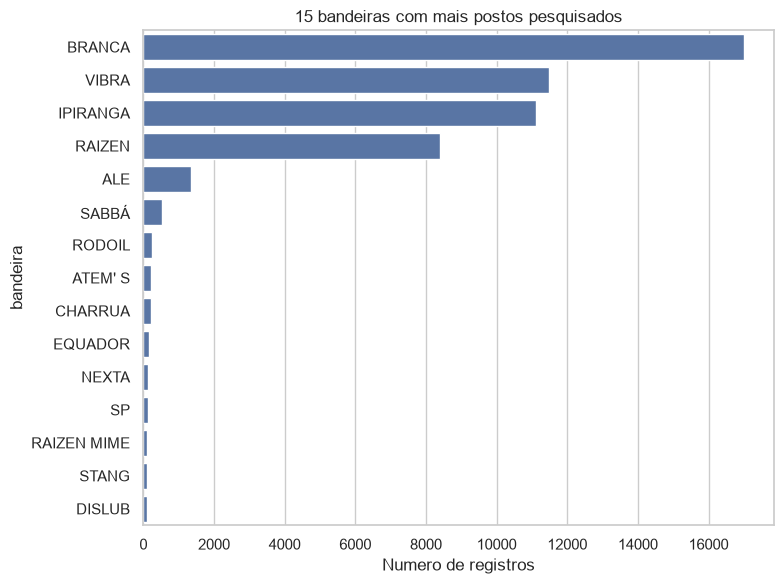

In [17]:
top_bandeiras = df['bandeira'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_bandeiras.values, y=top_bandeiras.index, ax=ax, orient='h')
ax.set_title('15 bandeiras com mais postos pesquisados')
ax.set_xlabel('Numero de registros')
plt.tight_layout()
plt.show()

**Resultado:** a distribuicao por bandeira e bem menos concentrada que por estado/produto — nenhuma bandeira domina o dataset. Por isso `bandeira` fica de fora das features numericas por enquanto (so `produto` e `regiao` entram como categoricas no preprocessador), mas continua disponivel nas tabelas de inspecao de anomalias.

## 8. Explorando possiveis anomalias (visual, sem treinar modelo)

Como referencia — e so como EDA, sem ajustar nenhum modelo de sklearn — vemos quantos registros ficam a mais de 3 desvios-padrao da media de preco do seu proprio grupo (estado + produto). Isso da uma nocao de escala: quantos casos 'obviamente estranhos' ja aparecem so com estatistica descritiva, antes de qualquer IsolationForest/LOF/OneClassSVM.

Esse primeiro criterio (z-score classico) e só o ponto de partida — logo abaixo comparamos com dois metodos mais robustos (z-score modificado com mediana/MAD e cercas de Tukey) para checar se a contagem de "casos estranhos" se sustenta independente do metodo escolhido.

In [18]:
grupo = df.groupby(['estado', 'produto'])['valor_venda']
media_grupo = grupo.transform('mean')
desvio_grupo = grupo.transform('std')
z_score = (df['valor_venda'] - media_grupo) / desvio_grupo

candidatos_outlier = df[z_score.abs() > 3]
print('Registros com |z-score| > 3 dentro do grupo estado+produto:', len(candidatos_outlier))
print(f'Isso e {len(candidatos_outlier) / len(df):.2%} do total — poucos, como esperado.')
candidatos_outlier[['estado', 'municipio', 'revenda', 'produto', 'valor_venda', 'bandeira']].sort_values('valor_venda', ascending=False).head(10)

Registros com |z-score| > 3 dentro do grupo estado+produto: 396
Isso e 0.76% do total — poucos, como esperado.


,estado,municipio,revenda,produto,valor_venda,bandeira
46391,SP,BARUERI,AUTO POSTO DUQUE CONDE ALPHAVILLE LTDA,GASOLINA ADITIVADA,9.59,VIBRA
34972,SP,BARUERI,FGN COMERCIAL LTDA,GASOLINA ADITIVADA,9.49,VIBRA
34987,SP,BARUERI,CENTRO AUTOMOTIVO ALPHA CENTER LTDA,GASOLINA ADITIVADA,9.49,VIBRA
3761,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
24986,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
46867,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
36192,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
14238,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
13118,SP,BARUERI,POSTO DE SERVICOS DUQUE ALPHAVILLE LTDA,GASOLINA ADITIVADA,9.29,VIBRA
13117,SP,BARUERI,POSTO DE SERVICOS DUQUE ALPHAVILLE LTDA,GASOLINA,9.29,VIBRA


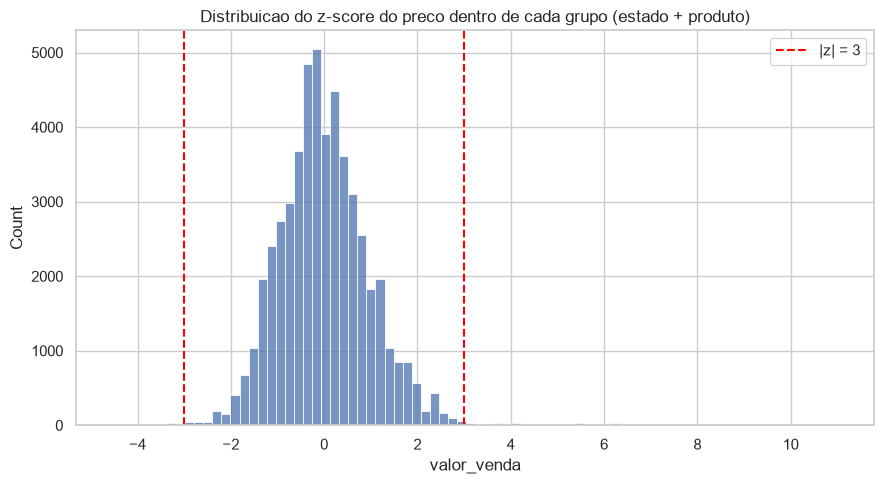

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(z_score.dropna(), bins=80, ax=ax)
ax.axvline(3, color='red', ls='--', label='|z| = 3')
ax.axvline(-3, color='red', ls='--')
ax.set_title('Distribuicao do z-score do preco dentro de cada grupo (estado + produto)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/eda_zscore_preco_grupo.png', dpi=120)
plt.show()

**Resultado:** apenas 396 registros (0,76% do total) passam de 3 desvios-padrao do seu grupo — confirma numericamente que anomalias sao raras neste dataset, na faixa de 1% ou menos, coerente com o `contamination` inicial de 2% usado como baseline no notebook 02. O histograma do z-score mostra uma distribuicao concentrada perto de zero com caudas curtas, exatamente o padrao esperado quando poucos pontos sao verdadeiramente anomalos.

### 8.1 O problema do z-score classico: efeito de mascaramento (masking)

O z-score acima usa **media e desvio-padrao** do proprio grupo — mas media e desvio-padrao nao sao robustos: um unico valor extremo ja distorce os dois. Isso cria um problema conhecido em estatistica robusta chamado **efeito de mascaramento**: quanto mais extremo (ou mais numeroso) for um outlier, mais ele infla o desvio-padrao do grupo, o que aumenta o denominador do z-score e "esconde" tanto a si mesmo quanto outros pontos moderadamente anomalos — na pratica, o metodo usado para detectar outliers e contaminado pelos proprios outliers que deveria detectar. Formalmente, media e desvio-padrao tem **ponto de ruptura (breakdown point) de 0%**: basta uma observacao arbitrariamente extrema para levar a estimativa a qualquer valor.

A alternativa classica e o **z-score modificado de Iglewicz & Hoaglin**, que troca media/desvio-padrao por **mediana/MAD** (median absolute deviation), com ponto de ruptura de 50% — ou seja, ate quase metade dos dados de um grupo pode ser extrema sem distorcer a referencia:

$$z_{modificado} = 0{,}6745 \times \frac{x - \text{mediana}}{\text{MAD}}$$

A constante 0,6745 torna o MAD comparavel ao desvio-padrao sob normalidade, e o limiar recomendado (NIST/Iglewicz & Hoaglin) e |z_modificado| > 3,5 em vez de 3.

In [20]:
mediana_grupo = grupo.transform('median')
mad_grupo = grupo.transform(lambda x: stats.median_abs_deviation(x, scale=1.0))

z_modificado = 0.6745 * (df['valor_venda'] - mediana_grupo) / mad_grupo
flag_robusto = z_modificado.abs() > 3.5

print('Registros com |z-score modificado| > 3.5:', flag_robusto.sum(), f'({flag_robusto.mean():.2%} do total)')
print('Para comparacao, o z-score classico (secao anterior) marcou:', (z_score.abs() > 3).sum())

Registros com |z-score modificado| > 3.5: 945 (1.81% do total)
Para comparacao, o z-score classico (secao anterior) marcou: 396


**Resultado:** o metodo robusto marca **945 registros (1,81%)**, mais que o **dobro** dos 396 (0,76%) do z-score classico — evidencia direta do efeito de mascaramento discutido acima: 582 registros so aparecem como anomalos quando trocamos media/desvio-padrao por mediana/MAD, porque no metodo classico esses mesmos outliers (e outros ainda mais extremos no grupo) infla­vam o desvio-padrao o suficiente para se camuflar. Ha tambem 33 registros marcados so pelo metodo classico — casos de grupos pequenos ou pouco variaveis onde o denominador de qualquer um dos dois metodos fica sensivel a ruido.

**Uma ressalva honesta sobre o metodo robusto:** em 4 combinacoes (estado, produto) o MAD do grupo e exatamente zero (mais da metade dos precos do grupo e identica a mediana — grupos homogeneos, entre 4 e 271 postos). Nesses grupos, qualquer preco diferente da mediana produz um z-score modificado infinito e e automaticamente marcado como anomalia — isso responde por 156 dos 945 registros robustos (~16,5%). Nao "corrigimos" isso escondendo o caso: e uma limitacao real e conhecida de estatisticas baseadas em MAD quando o proprio MAD colapsa a zero, e reforca por que os modelos multivariados dos proximos notebooks (que olham o preco junto de produto/regiao de forma continua, nao grupo a grupo) sao mais robustos na pratica do que qualquer regra univariada isolada.

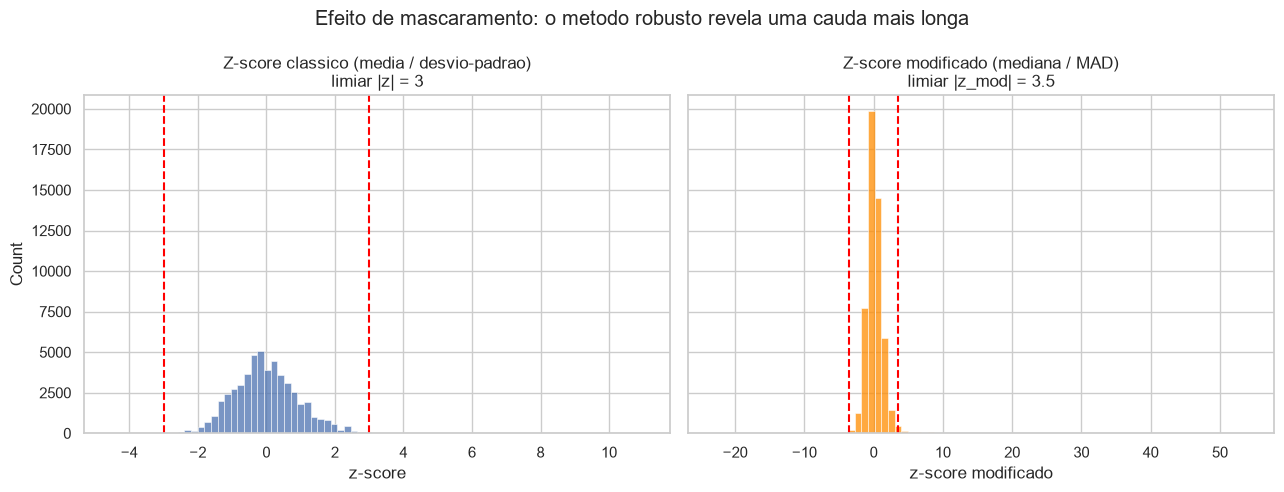

In [21]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

sns.histplot(z_score.dropna(), bins=80, ax=eixos[0])
eixos[0].axvline(3, color='red', ls='--')
eixos[0].axvline(-3, color='red', ls='--')
eixos[0].set_title('Z-score classico (media / desvio-padrao)\nlimiar |z| = 3')
eixos[0].set_xlabel('z-score')

sns.histplot(z_modificado.replace([np.inf, -np.inf], np.nan).dropna(), bins=80, ax=eixos[1], color='darkorange')
eixos[1].axvline(3.5, color='red', ls='--')
eixos[1].axvline(-3.5, color='red', ls='--')
eixos[1].set_title('Z-score modificado (mediana / MAD)\nlimiar |z_mod| = 3.5')
eixos[1].set_xlabel('z-score modificado')

fig.suptitle('Efeito de mascaramento: o metodo robusto revela uma cauda mais longa')
plt.tight_layout()
plt.savefig('../reports/eda_comparacao_zscore_classico_vs_robusto.png', dpi=120)
plt.show()

### 8.2 Uma terceira referencia: as cercas de Tukey (IQR)

O metodo classico de boxplot (Tukey, 1977) marca como outlier qualquer ponto fora de `[Q1 - 1,5×IQR, Q3 + 1,5×IQR]`, onde IQR = Q3 - Q1. Assim como o metodo robusto, usa estatisticas de ordem (quartis) em vez de media/desvio-padrao — mas com um ponto de ruptura menor (25%, nao 50%) e uma limitacao propria: em distribuicoes assimetricas (e ja vimos que os 3 produtos tem assimetria positiva de 0,70 a 1,19), a cerca superior fica "apertada" demais em relacao a cauda direita real, tendendo a marcar como outlier uma fatia maior da cauda longa do que faria sentido — precos legitimamente altos, nao so erros.

In [22]:
q1 = grupo.transform(lambda x: x.quantile(0.25))
q3 = grupo.transform(lambda x: x.quantile(0.75))
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

flag_tukey = (df['valor_venda'] < limite_inferior) | (df['valor_venda'] > limite_superior)
print('Registros fora das cercas de Tukey:', flag_tukey.sum(), f'({flag_tukey.mean():.2%} do total)')

Registros fora das cercas de Tukey: 1532 (2.93% do total)


In [23]:
flag_classico = z_score.abs() > 3

resumo_metodos = pd.DataFrame({
    'metodo': ['Classico (media/desvio, |z|>3)', 'Robusto (mediana/MAD, |z_mod|>3.5)', 'Tukey IQR (1.5x)'],
    'n_marcados': [flag_classico.sum(), flag_robusto.sum(), flag_tukey.sum()],
    'pct_marcados': [flag_classico.mean(), flag_robusto.mean(), flag_tukey.mean()],
})
print(resumo_metodos.to_string(index=False))

print('\nConcordancia entre os 3 metodos:')
print('  Marcados pelos 3 ao mesmo tempo :', (flag_classico & flag_robusto & flag_tukey).sum())
print('  Marcados por pelo menos 1        :', (flag_classico | flag_robusto | flag_tukey).sum())
print('  So pelo robusto (nem classico, nem Tukey):', (flag_robusto & ~flag_classico & ~flag_tukey).sum())

                            metodo  n_marcados  pct_marcados
    Classico (media/desvio, |z|>3)         396      0.007566
Robusto (mediana/MAD, |z_mod|>3.5)         945      0.018056
                  Tukey IQR (1.5x)        1532      0.029272

Concordancia entre os 3 metodos:
  Marcados pelos 3 ao mesmo tempo : 361
  Marcados por pelo menos 1        : 1568
  So pelo robusto (nem classico, nem Tukey): 33


**Resultado:** os tres metodos discordam bastante em volume — classico 396 (0,76%), robusto 945 (1,81%), Tukey 1.532 (2,93%) — mas concordam em 361 registros marcados **simultaneamente pelos tres**, um nucleo de casos que qualquer criterio razoavel classificaria como anomalo. A uniao dos tres chega a 1.568 registros (3,0% do total); so 33 aparecem exclusivamente no robusto (nem no classico, nem no Tukey) — a maior parte do que o robusto encontra a mais tambem e capturada pelo Tukey, o que da confianca de que nao e um artefato isolado do MAD.

**Sintese estatistica desta secao:** nenhum metodo univariado sozinho e "o certo" — cada um assume algo diferente (normalidade implicita no z-score classico; robustez a custo de um limiar de corte um pouco arbitrario no robusto; simetria aproximada no Tukey, que sabemos ser violada aqui). Por isso este notebook usa os tres so como **triangulacao exploratoria** — para dimensionar a escala do problema (algo entre 0,8% e 3% dos registros, dependendo do criterio) e verificar que a conclusao "anomalias sao raras" e robusta ao metodo escolhido. A deteccao de verdade fica a cargo dos modelos multivariados dos notebooks 02-04 (IsolationForest, LOF, OneClassSVM, EllipticEnvelope), que nao dependem de um unico limiar univariado nem assumem normalidade.

## 9. Conclusoes da EDA

- O dataset tem 52.336 registros, sem nulos e sem duplicadas, com uma unica coluna numerica relevante (`valor_venda`) e fortes efeitos de grupo por `estado` e `produto`.
- **`valor_venda` nao e normal em nenhum dos 3 produtos** (teste de D'Agostino-Pearson, p≈0 nos tres) e tem assimetria positiva (0,70 a 1,19) — gasolina e gasolina aditivada sao ainda fortemente leptocurticas (curtose em excesso 5,3-5,7). Isso descarta metodos que assumem normalidade e justifica estatisticamente as escolhas robustas/nao-parametricas usadas no restante do projeto (mediana em vez de media, Kruskal-Wallis em vez de ANOVA).
- **O efeito de regiao/estado sobre o preco e estatisticamente significativo e de tamanho pratico relevante**, nao so visual: Kruskal-Wallis rejeita H0 em todos os produtos (p≈0), com tamanho de efeito ε² entre 0,10 e 0,49 — e granularidade por **estado** explica bem mais variacao do que por **regiao**, dando suporte estatistico direto a escolha de `estado + produto` como grupo de referencia em `ReferenciaPrecos` (notebook 02). Preco bruto sozinho **nao** e uma boa feature de anomalia: R$ 6,50 e comum no Acre (mediana de gasolina R$ 7,39) e seria um outlier forte no Piaui (mediana R$ 5,79).
- **A contagem de anomalias depende do metodo, mas a ordem de grandeza nao**: z-score classico (media/desvio) marca 396 registros (0,76%), mas sofre de efeito de mascaramento — o proprio desvio-padrao e inflado pelos outliers que deveria detectar. O z-score modificado (mediana/MAD, robusto a outliers) marca mais que o dobro, 945 (1,81%); as cercas de Tukey marcam 1.532 (2,93%). Os tres concordam num nucleo de 361 registros. Confirma que anomalias sao raras (entre ~1% e ~3% do total, dependendo do criterio) e que nenhum metodo univariado isolado deve ser tomado como definitivo.
- Nao ha rotulo de fraude/erro: a avaliacao de precision/recall dos modelos vai precisar de anomalias sinteticas injetadas (feito no notebook `04_avaliacao_tuning`).

**Proximo passo:** `02_preprocessing_baseline.ipynb` — split treino/teste, engenharia de features (desvio vs. mediana do grupo, ajustado somente no treino) e um modelo baseline de IsolationForest.